# COE 311K Final Project, Part 3

Individual project by Thomas Thomas (tlt2748)

## Note - I completed bonus challenge 1, located at the end of this report.

## Review of Part 2

My system is the highly damped mechanical system. It has a stiffness parameter of $10^4$ (slow-moving time scale / fast-moving time scale), meaning the problem is stiff. Physically, this means the spring-damper system responds very quickly to fast transient forces while simultaneously following slow transient forces.

The solutions from part 2 utilize an implicit solver named Euler's Backward, which in turn used Newton-Raphson. Each fixed time step, it would evaluate a best-guess equation for the next y-value using Newton-Raphson, then use that best-guess future y-value to evaluate the differential equation at a future time (hence Euler's Backward), using that future-biased slope to retain accuracy given much larger step sizes than traditional explicit solvers like Euler's Forward.

## Newton-Raphson Damping Implementation

When regular Newton-Raphson isn't working very well, we can use a damping factor $\alpha$ to suppress large updates. This is useful when step size is too large, when the initial guess is unusually far off, or when the update overshoots and diverges.

The implementation of this is with a line search technique. Every time we call the Newton-Raphson function, we check if the residual decreases; otherwise, we double the damping effect (by halving $\alpha$) until it does (or until $\alpha$ becomes too small).

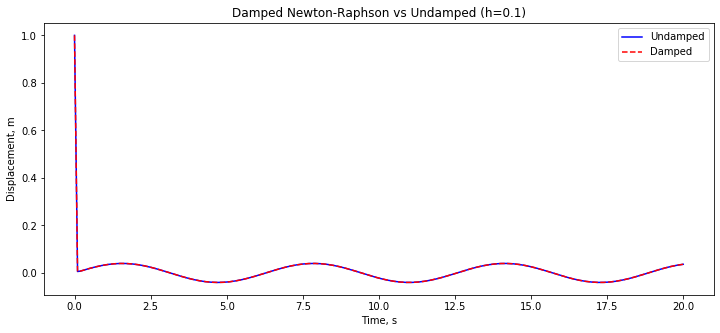

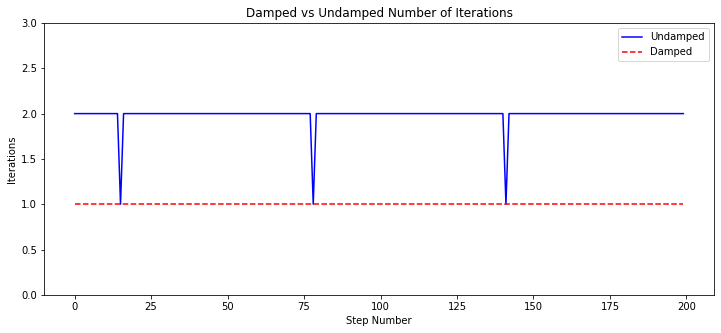

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# System Parameters
k = 5000 # N/m
c = 1 # Ns/m
t0 = 0 # s
tf = 20 # s
x0 = 1 # m

# System derivative function
f = lambda x, t: -(k/c)*x + 200*np.sin(t)/c

# Newton-Raphson internal derivative
g_prime = lambda h: 1 + h*(k/c)

### Methods

# Basic Newton-Raphson step
def nr_step_basic(f, x_n, t, h, tol=1e-4, iterations=50):
    x_n1 = x_n
    for i in range(1, iterations+1):
        g_val = x_n1 - x_n - h * f(x_n1, t+h)
        if abs(g_val) < tol:
            return x_n1, i, True
        delta = -g_val / g_prime(h)
        if abs(delta) < tol:
            return x_n1 + delta, i, True
        x_n1 += delta
    return x_n1, iterations, False

# Damped Newton-Raphson step
def nr_step_damped(f, x_n, t, h, tol=1e-4, iterations=50):
    x_n1 = x_n
    for i in range(1, iterations+1):
        g_val = x_n1 - x_n - h * f(x_n1, t+h)
        if abs(g_prime(h)) < tol:
            return x_n1, i, True
        
        # Line search
        alpha = 1.0
        delta = -g_val / g_prime(h)
        j = 0 # counter
        while True:
            j += 1
            x_new = x_n1 + alpha * delta
            g_new = abs(x_new - x_n - h * f(x_new, t+h))
            if g_new < abs(g_val):
                return x_new, i, True
            alpha /= 2
            if alpha < tol:
                break
        
        x_n1 = x_new
    return x_n1, iterations, False
        
# Basic Euler's Backward, can use either Newton-Raphson function
def euler_backward_basic(f, x0, t0, tf, h, nr_func, tol=1e-4, iterations=50):
    t_vals = np.arange(t0, tf+h, h)
    x_vals = np.zeros_like(t_vals)
    nr_iterations = np.zeros(t_vals.size-1)
    nr_convergence = np.zeros(t_vals.size-1)
    x_vals[0] = x0
    for i in range(len(t_vals)-1):
        x_vals[i+1], nr_iterations[i], nr_convergence[i] = nr_func(f, x_vals[i], t_vals[i], h, tol, iterations)
    return t_vals, x_vals, nr_iterations, nr_convergence

# Damping demonstration
h = 0.1
undamped = euler_backward_basic(f, x0, t0, tf, h, nr_step_basic)
damped   = euler_backward_basic(f, x0, t0, tf, h, nr_step_damped)

plt.figure(figsize=(12,5))
plt.plot(undamped[0], undamped[1], 'b-', label="Undamped")
plt.plot(damped[0], damped[1], 'r--', label="Damped")
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title(f"Damped Newton-Raphson vs Undamped (h={h})")
plt.legend()
plt.show()

# Iterations
plt.figure(figsize=(12,5))
plt.plot(range(len(undamped[2])), undamped[2], 'b-', label="Undamped")
plt.plot(range(len(damped[2])), damped[2], 'r--', label="Damped")
plt.xlabel("Step Number")
plt.ylabel("Iterations")
plt.ylim(0,3)
plt.title("Damped vs Undamped Number of Iterations")
plt.legend()
plt.show()

## Adaptive Step Size Implementation

The error in one full Newton-Raphson step can be estimated by taking two half-steps and comparing the result. The error can be used to adapt the step size to the problem in real time.

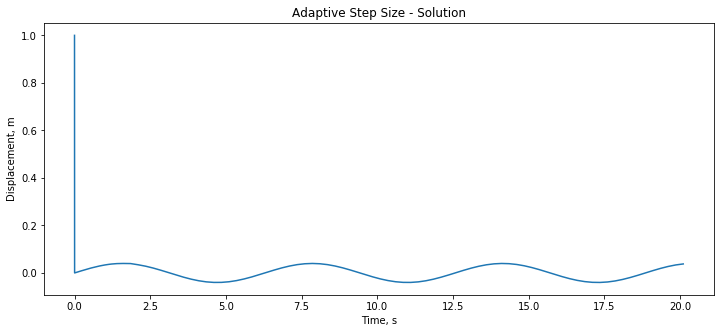

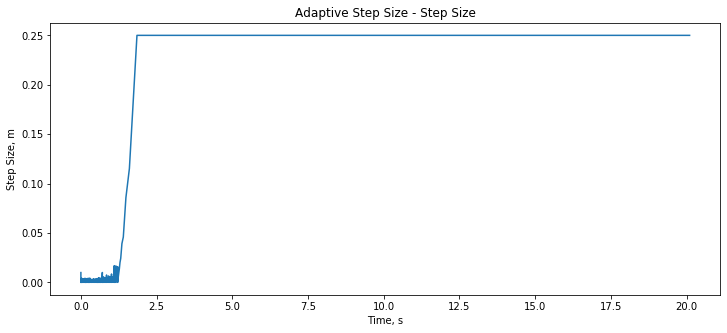

In [2]:
# Modular higher-accuracy function (for bonus RK2 implementation later)
def two_halves(f, x_n, t, h, tol=1e-4, iterations=50):
    x_n1_2, _, _ = nr_step_basic(f, x_n, t, h/2, tol, iterations)
    x_n1 = nr_step_basic(f, x_n1_2, t+(h/2), h/2, tol, iterations)
    return x_n1

# Modular step size function (for bonus PI controller implementation later)
def proportional_h(tol, err, prev_err):
    return np.sqrt(tol / (err + 1e-10))

# Euler's Backward with Adaptive Step Size
def euler_backward_adaptive(f, x0, t0, tf, h0, single_func=nr_step_basic, complex_func=two_halves, step_size_func=proportional_h, tol=1e-4, min_h=1e-7, iterations=50):
    t_vals = [t0]
    x_vals = [x0]
    nr_iterations = []
    nr_convergence = []
    h_vals = [h0]
    errs = [0]
    h = h0
    
    while t_vals[-1] <= tf:
        single_step = single_func(f, x_vals[-1], t_vals[-1], h, tol, iterations)
        complex_step = complex_func(f, x_vals[-1], t_vals[-1], h, tol, iterations)
        # New step size based on estimated error
        err = abs(complex_step[0] - single_step[0])
        h *= step_size_func(tol, err, errs[-1])
        # Step size safety
        h = max(min_h, min(h, max(0.25, h_vals[-1]*0.5)))
        # Decision
        if err < tol:
            x_i1, nr_i, nr_c = complex_step
            x_vals.append(x_i1)
            nr_iterations.append(nr_i)
            nr_convergence.append(nr_c)
            h_vals.append(h)
            t_vals.append(t_vals[-1] + h)
            errs.append(err)
    
    return t_vals, x_vals, nr_iterations, nr_convergence, h_vals

# Adaptive step size plots
h0 = 0.01
adaptive = euler_backward_adaptive(f, x0, t0, tf, h0, tol=1e-6, min_h=1e-7)
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[1])
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title("Adaptive Step Size - Solution")
plt.show()
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[4])
plt.xlabel("Time, s")
plt.ylabel("Step Size, m")
plt.title("Adaptive Step Size - Step Size")
plt.show()

The step size starts small to accommodate the fast initial motion, then adapts to the slow moving forcing function!

## Performance Analysis

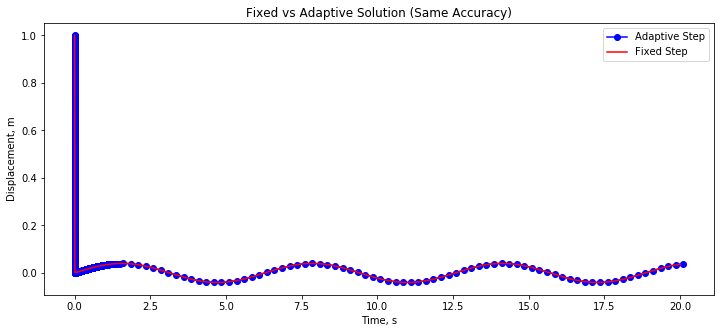

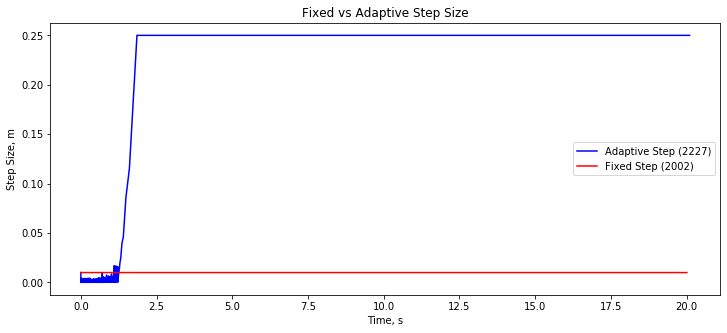

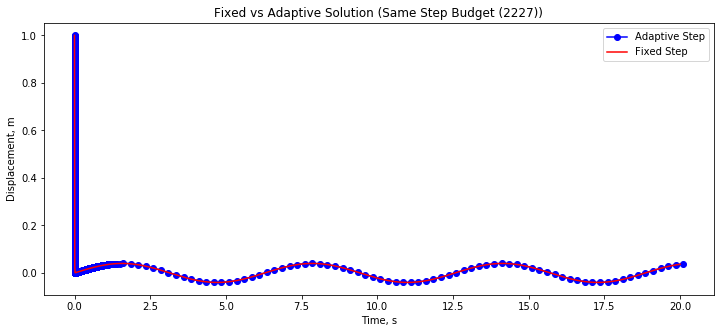

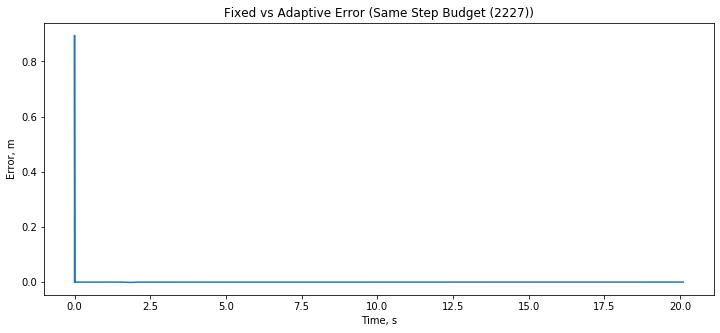

In [3]:
# Same target accuracy
tol = 1e-6
h = 0.01 # h0 for adaptive
basic = euler_backward_basic(f, x0, t0, tf, h, nr_step_basic, tol=tol)
adaptive = euler_backward_adaptive(f, x0, t0, tf, h, nr_step_basic, tol=tol)

# Recalculate h for basic version with same step budget
h2 = (tf - t0) / len(adaptive[4])
basic2 = euler_backward_basic(f, x0, t0, tf, h2, nr_step_basic, tol=tol)

# Plot solutions (same target accuracy)
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[1], 'bo-', label="Adaptive Step")
plt.plot(basic[0], basic[1], 'r-', label="Fixed Step")
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title("Fixed vs Adaptive Solution (Same Accuracy)")
plt.legend()
plt.show()

# Plot step sizes
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[4], 'b-', label=f"Adaptive Step ({len(adaptive[0])})")
plt.plot(basic[0], np.ones_like(basic[0])*h, 'r-', label=f"Fixed Step ({len(basic[0])})")
plt.xlabel("Time, s")
plt.ylabel("Step Size, m")
plt.title("Fixed vs Adaptive Step Size")
plt.legend()
plt.show()

# Plot solutions (same step budget)
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], adaptive[1], 'bo-', label="Adaptive Step")
plt.plot(basic2[0], basic2[1], 'r-', label="Fixed Step")
plt.xlabel("Time, s")
plt.ylabel("Displacement, m")
plt.title(f"Fixed vs Adaptive Solution (Same Step Budget ({len(adaptive[0])}))")
plt.legend()
plt.show()

# Same step budget error
err = []
for i, t in enumerate(adaptive[0]):
    guess_i = np.clip(np.searchsorted(basic2[0], t, side="left")-1, 0, len(basic2[0])-2)
    guess_frac = (t-basic2[0][guess_i]) / (basic2[0][guess_i+1]-basic2[0][guess_i])
    basic_linked = (1-guess_frac)*basic2[1][guess_i] + guess_frac*basic2[1][guess_i+1]
    err.append(basic_linked - adaptive[1][i])
    
plt.figure(figsize=(12,5))
plt.plot(adaptive[0], err)
plt.xlabel("Time, s")
plt.ylabel("Error, m")
plt.title(f"Fixed vs Adaptive Error (Same Step Budget ({len(adaptive[0])}))")
plt.show()

| Comparison | Fixed Step Size | Adaptive Step Size |
| :-: | :-: | :-: |
| Same Accuracy | 2002 Equal Steps | 2227 Dynamic Steps |
| Same Step Budget | 2227 Equal Steps | 2227 Dynamic Steps |

Having the same step budget forced the fixed step size method into more accuracy than it needed.

## Robustness Testing

Adaptive solver handles both large h0 and very tight tolerance gracefully:

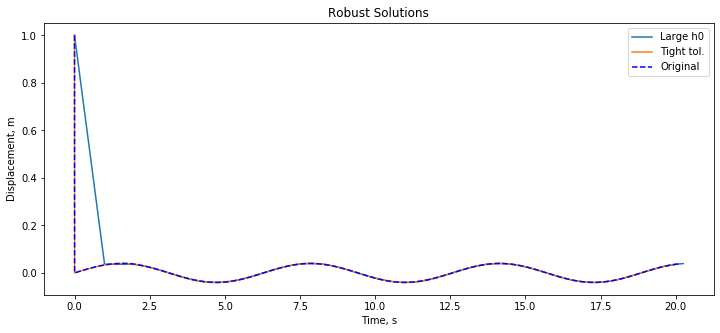

In [4]:
import warnings

# Large h0
h0 = 2.0
tol = 1e-4
large_h0 = euler_backward_adaptive(f, x0, t0, tf, h0, nr_step_basic, tol=tol)

# Tight tolerance
h0 = 0.01
tol = 1e-8
tight_tol = euler_backward_adaptive(f, x0, t0, tf, h0, nr_step_basic, tol=tol, min_h=1e-9)

# Plot results (original, large h0, tight tolerance)
plt.figure(figsize=(12,5))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Hide the UserWarning from the tight tolerance set having a large number of points
    plt.plot(large_h0[0], large_h0[1], label="Large h0")
    plt.plot(tight_tol[0], tight_tol[1], label="Tight tol.")
    plt.plot(adaptive[0], adaptive[1], 'b--', label="Original")
    plt.xlabel("Time, s")
    plt.ylabel("Displacement, m")
    plt.title("Robust Solutions")
    plt.legend()
    plt.show()

## Conclusions

Damping is necessary with unneccessarily large step sizes, nonlinear functions, or when the update function temporarily diverges. Adaptive step sizes are worth the complexity when the system has fast transients mixed with slow ones - the adaptive step size allows the solver to focus more on the parts that need its attention and less on the slow transients in between. I learned that even for somewhat simple systems such as the spring-mass-damper that I chose (as opposed to large mechanical/electrical systems with many updates), the adaptive step size and damping still have a noticable effect on the solution's accuracy and evaluation time.

## Bonus 1: PI Controller for Step Size

Replace the simple proportional control of step size $h$ with a Proportional-Integral controller:

$$ h_{n+1}=h_n\times(\frac{tol}{err_n})^{k_P}\times(\frac{err_{n-1}}{err_n})^{k_I} $$

Where $k_P=0.7$ and $k_I=0.4$.

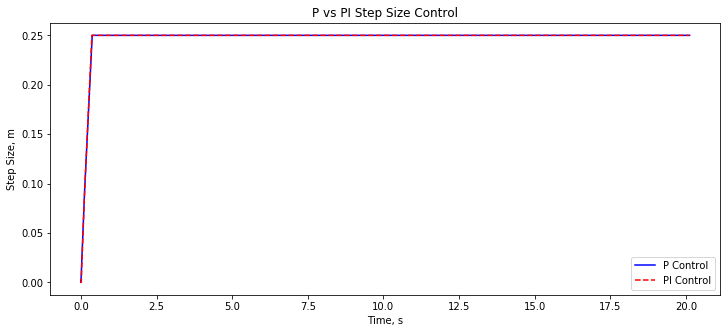

In [5]:
h0 = 0.001
kp = 0.7
ki = 0.4

# Using modular adaptive Euler's Backward function from earlier,
# where the input step_size_func is the factor to multiply step size h.
controlled_h = lambda tol, err, prev_err: np.power(tol / (err+1e-10), kp) * np.power(prev_err / (err+1e-10), ki)

# Plot step sizes over time
proportional = euler_backward_adaptive(f, x0, t0, tf, h0, step_size_func=proportional_h)
controlled   = euler_backward_adaptive(f, x0, t0, tf, h0, step_size_func=controlled_h, min_h=2e-6)
plt.figure(figsize=(12,5))
plt.plot(proportional[0], proportional[4], 'b-', label="P Control")
plt.plot(controlled[0], controlled[4], 'r--', label="PI Control")
plt.xlabel("Time, s")
plt.ylabel("Step Size, m")
plt.title("P vs PI Step Size Control")
plt.legend()
plt.show()

Both are very similar because of how this stiff problem is set up. There is never a reason to go back to smaller step sizes because the fast transient is only at the start.